from the previous hyperparameter tuning notebook, three models were tested and these were the results:

|model|Mean RMSE|STD RMSE|
|-----|---------|--------|
|Ridge|0.136576|0.023301|
|RandomForest|0.142412|0.008456|
|LightGBM|0.130961|0.0104067|

from the results, LightGBM has the lowest average RMSE, but it's variance is not the best. In this notebook I will analyse the errors made by LightGBM and its variance, and also its interpretability, to get better information on the final model selection

# Setup and Loading

In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

In [2]:
import numpy as np
import pandas as pd
import joblib

from src.data import load_train_data
from src.features import add_engineered_features

data = load_train_data()
X = add_engineered_features(data)
y = np.log1p(data['SalePrice'])

MODELS_DIR = ROOT / "models"
ridge_pipe = joblib.load(MODELS_DIR/ "ridge_final.pkl")
lgb_pipe = joblib.load(MODELS_DIR / "lgbm_final.pkl")
rfr_pipe = joblib.load(MODELS_DIR /"rfr_final.pkl")

In [3]:
# produce Out-Of-Fold predictions
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error


cv = KFold(n_splits=5, shuffle= True, random_state=42)
ridge_pred = cross_val_predict(ridge_pipe, X, y, cv=cv, method='predict', n_jobs=-1)
lgb_pred = cross_val_predict(lgb_pipe, X, y, cv=cv, method='predict', n_jobs=-1)
rfr_pred = cross_val_predict(rfr_pipe, X, y, cv=cv, method='predict', n_jobs=-1)

ridge_rmse = np.sqrt(mean_squared_error(y, ridge_pred))
lgb_rmse = np.sqrt(mean_squared_error(y, lgb_pred))
rfr_rmse = np.sqrt(mean_squared_error(y, rfr_pred))

print('Ridge OOF RMSE:', ridge_rmse)
print('LGB OOF RMSE:', lgb_rmse)
print('RFR OOF RMSE:', rfr_rmse)

Ridge OOF RMSE: 0.14701048328624955
LGB OOF RMSE: 0.13685615941445264
RFR OOF RMSE: 0.1429946318942553


The OOF RMSE I got is generally worse than the previous ones I got during parameter tuning stage, it is expected, as there is now no average effect, and a larger amount of data were used.

But the difference is not too big, suggesting the CV scores weren't too optimistic

# Error Analysis

In [4]:
# analysis dataframe
analysis_df = pd.DataFrame({
  'y_true': y,
  'ridge_pred': ridge_pred,
  'lgb_pred': lgb_pred,
  'rfr_pred': rfr_pred
}, index=X.index)

analysis_df['ridge_residual'] = analysis_df['y_true'] - analysis_df['ridge_pred']
analysis_df['lgb_residual'] = analysis_df['y_true'] - analysis_df['lgb_pred']
analysis_df['rfr_residual'] = analysis_df['y_true'] - analysis_df['rfr_pred']


While the errors have been calculated, but in order to make sense of the errors, there needs to be some basis for the errors to be based on, to show what kind of houses the models are more likely to make errors on 

These basis must use features that are broad enough, and not something niche and rare, for example PoolQC.

I will consider: 
1. new vs old
2. location
3. quality and conditions

In [5]:
analysis_df['Neighborhood'] = data['Neighborhood'].values
analysis_df['HouseSaleAge'] = X['HouseSaleAge'].values
analysis_df['OverallQual'] = data['OverallQual'].values
analysis_df['OverallCond'] = data['OverallCond'].values

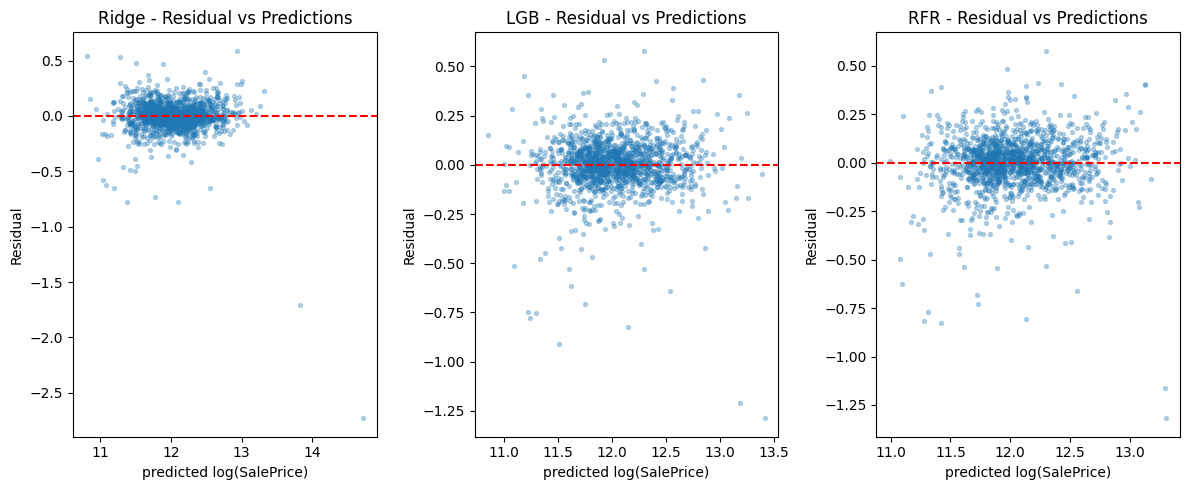

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

#Plot Ridge
plt.subplot(1,3,1)
plt.scatter(analysis_df['ridge_pred'],analysis_df['ridge_residual'], alpha=0.3, s=8)
plt.axhline(0, color='red', linestyle='--')
plt.title("Ridge - Residual vs Predictions")
plt.xlabel("predicted log(SalePrice)")
plt.ylabel("Residual")

# Plot LGB
plt.subplot(1,3,2)
plt.scatter(analysis_df['lgb_pred'],analysis_df['lgb_residual'], alpha=0.3, s=8)
plt.axhline(0, color='red', linestyle='--')
plt.title("LGB - Residual vs Predictions")
plt.xlabel("predicted log(SalePrice)")
plt.ylabel("Residual")

# Plot RFR
plt.subplot(1,3,3)
plt.scatter(analysis_df['rfr_pred'],analysis_df['rfr_residual'], alpha=0.3, s=8)
plt.axhline(0, color='red', linestyle='--')
plt.title("RFR - Residual vs Predictions")
plt.xlabel("predicted log(SalePrice)")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

As plots are visuals only, we will need data and calculations to further back up the conclusions


In [7]:
# Bias 
# check correlation between prediction and residual 

print('Ridge bias: ', np.corrcoef(ridge_pred, y - ridge_pred)[0,1])
print('LGB bias: ',np.corrcoef(lgb_pred, y - lgb_pred)[0,1])
print('RandomForest bias: ',np.corrcoef(rfr_pred, y - rfr_pred)[0,1])
print()

# residual standard deviaion
print('Ridge residual S.D. : ', np.std(y-ridge_pred) )
print('LGB residual S.D. : ', np.std(y-lgb_pred) )
print('RandomForest residual S.D. : ', np.std(y-rfr_pred) )


Ridge bias:  -0.08434581901632691
LGB bias:  0.0218409996491995
RandomForest bias:  0.06226818491877949

Ridge residual S.D. :  0.14700165585965747
LGB residual S.D. :  0.1368464512329051
RandomForest residual S.D. :  0.14298344181888728


### interpretations

#### Bias: 
- Ridge has the biggest absolute bias, it is negative which means that there is underprediction as price increases
- Light GBM has the smallest absolute bias, it is the best performing model in terms of bias of the three
- Random Forest: Moderate absolute bias of the three, it is positive, meaning that it has overprediction at higher prices

Among the three models, LightGBM has the least prediction-dependent bias 

#### Residual Variance: 
- Ridge has the largest residual S.D. followed by Random Forest and the least is LightGBM
Visually on the plots, Ridge seems the most "packed" however the numbers show that it is of high variance, it could be because in terms of horizontal spread, for Ridge the predicted log(price) is more compressed than the other models, making it looks visually packed, it could be shrinking predictions toward mean and avoiding predicting extreme values

LightGBM achieves the lowest residual dispersion in this case 

As from the previous OOF RMSE analysis, LightGBM wins in terms of OOF RMSE, bias and variance, it clearly wins over other models 

However, all models underpredicts when it comes to expensive houses, as see from all the plots have dots at the right bottom corner



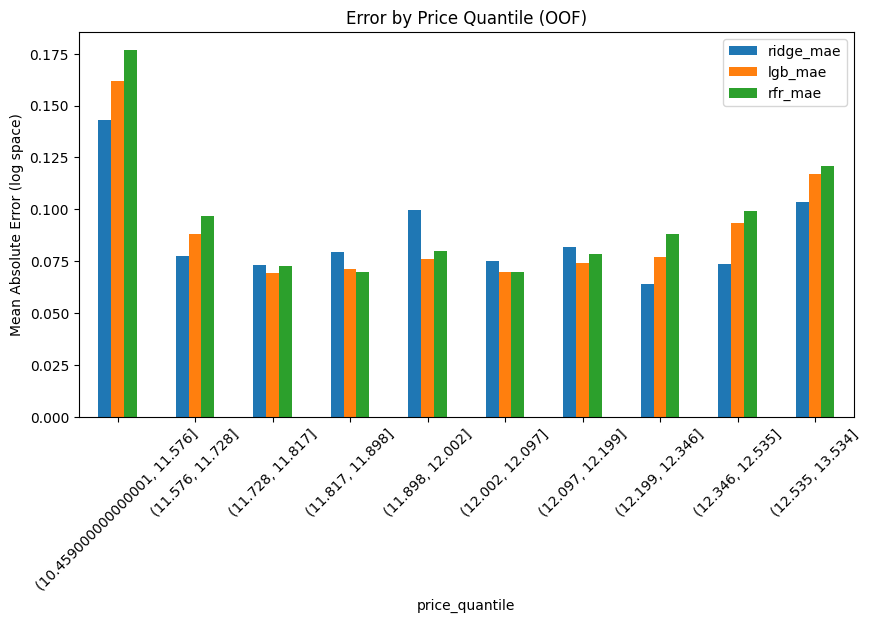

In [10]:
# Calculate error by price quantiles

analysis_df['price_quantile'] = pd.qcut(analysis_df['y_true'],q=10,duplicates='drop')

error_by_bin = (
  analysis_df
  .groupby('price_quantile', observed= True)[['ridge_residual', 'lgb_residual','rfr_residual']]
  .apply(lambda df: df.abs().mean())
  .rename(columns={'ridge_residual': 'ridge_mae', 'lgb_residual': 'lgb_mae', 'rfr_residual': 'rfr_mae'})
)

error_by_bin.plot(kind='bar', figsize=(10,5))
plt.ylabel("Mean Absolute Error (log space)")
plt.title('Error by Price Quantile (OOF)')
plt.xticks(rotation=45)
plt.show()

Here I calculated the mean absolute error of each models for deciles of SalePrice 

for each bin the model that made the lowest errors are: 
1. Ridge 
2. Ridge 
3. LGB
4. RFR
5. LGB
6. LGB & RFR
7. LGB
8. Ridge 
9. Ridge 
10. Ridge 

If counted by the number of wins for each quantile, Ridge has the most number of wins here, However, the wins of Ridge are mostly at the two ends of the SalePrices. However, for the middle quantiles where there is more data and the most densely populated, LGB wins more numerically. Considering lower OOF RMSE and better performance at the highest data density quantiles, I will say LGB wins 

Apart from this, it can be observed that errors are higher at the two extremes - all models struggle. And all models have a regional peak of error at the middle quantile

In [15]:
# Worst 5% cases of LGB 

n = int(len(analysis_df) * 0.05)
analysis_df['lgb_abs_error'] = analysis_df['lgb_residual'].abs()
worst_cases = analysis_df.sort_values('lgb_abs_error', ascending= False).head(n)

cols_for_inspect = ['y_true', 'lgb_pred', 'lgb_residual','Neighborhood','OverallQual','HouseSaleAge']
display_cols = [col for col in cols_for_inspect if col in worst_cases.columns]
worst_cases[display_cols].head(20)

,y_true,lgb_pred,lgb_residual,Neighborhood,OverallQual,HouseSaleAge
523,12.126764,13.415403,-1.288639,Edwards,10,0
1298,11.982935,13.191532,-1.208596,Edwards,10,0
30,10.596660,11.505422,-0.908762,IDOTRR,4,88
632,11.320566,12.145421,-0.824855,NWAmes,7,32
495,10.460271,11.241311,-0.781040,IDOTRR,4,89
968,10.542733,11.296552,-0.753819,OldTown,3,99
916,10.471978,11.219550,-0.747572,IDOTRR,2,57
462,11.041064,11.748733,-0.707669,Sawyer,5,44
1324,11.898195,12.539176,-0.640981,Somerst,8,1
410,11.002117,11.619964,-0.617848,Edwards,5,51


From these 20 rows, it is clear that there are a lot of negative residuals, model is overpredicting. Neighborhood IDOTRR, Edwards are frequently seen.

In [12]:
# learn more about these neighborhood 
data.groupby('Neighborhood')['SalePrice'].median().sort_values()

Neighborhood
MeadowV     88000.0
IDOTRR     103000.0
BrDale     106000.0
OldTown    119000.0
Edwards    121750.0
BrkSide    124300.0
Sawyer     135000.0
Blueste    137500.0
SWISU      139500.0
NAmes      140000.0
NPkVill    146000.0
Mitchel    153500.0
SawyerW    179900.0
Gilbert    181000.0
NWAmes     182900.0
Blmngtn    191000.0
CollgCr    197200.0
ClearCr    200250.0
Crawfor    200624.0
Veenker    218000.0
Somerst    225500.0
Timber     228475.0
StoneBr    278000.0
NoRidge    301500.0
NridgHt    315000.0
Name: SalePrice, dtype: float64

The medium price of IDOTRR, OldTown, and Edwards are of the lowest, from the 20 rows, the LGB model seems to overpredict when the quality is better or when the HouseSaleAge is younger, the model might think that the effects of these factors would outweigh that of neighborhood when actually not so 

# Model Interpretability (LightGBM)

In [20]:
# Analyse Feature Importance

preprocessor = lgb_pipe.named_steps['preprocessor']
lgb_model = lgb_pipe.named_steps['model']

feature_names = preprocessor.get_feature_names_out()

importances = lgb_model.feature_importances_ 

fi_df = (
  pd.DataFrame({
    'feature' : feature_names,
    'importance' : importances
  }).sort_values('importance', ascending= False)
)

# See the top 20 important features
fi_df.head(20)

,feature,importance
34,rest_num__TotalInHouseArea,1276
2,rest_num__LotArea,1127
7,rest_num__GrLivArea,868
231,num_ordinal__OverallCond,779
17,rest_num__GarageArea,708
3,rest_num__BsmtFinSF1,649
35,rest_num__HouseSaleAge,638
36,rest_num__RemodAge,634
230,num_ordinal__OverallQual,618
5,rest_num__BsmtUnfSF,614


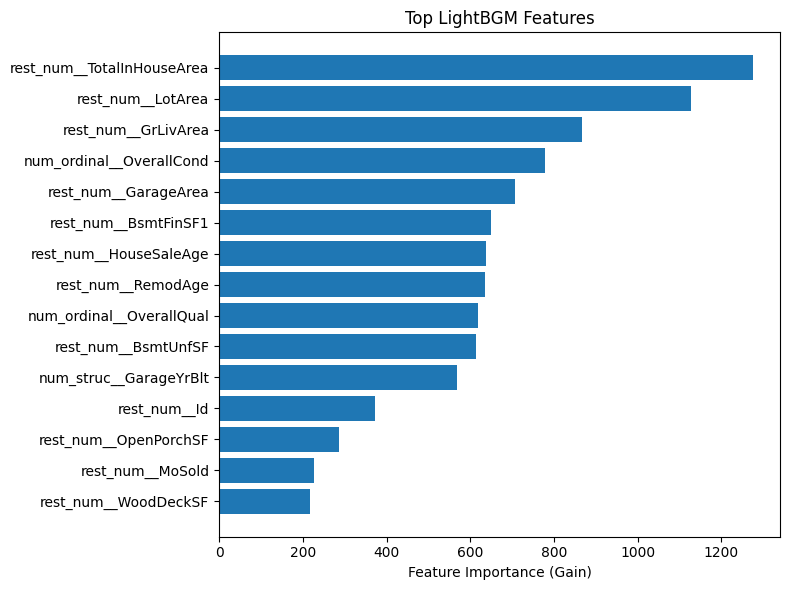

In [21]:
# plot top features

import matplotlib.pyplot as plt

top_n = 15
plt.figure(figsize=(8,6))
plt.barh(
  fi_df.head(top_n)['feature'][::-1],
  fi_df.head(top_n)['importance'][::-1]
)

plt.xlabel("Feature Importance (Gain)")
plt.title("Top LightBGM Features")
plt.tight_layout()
plt.show()

From the top features, it can be observed that LightGBM primarily uses size and area related features and age-related features to predict prices, this means most houses in the dataset has a monotonic relatioinship between area and age related features

There is one neighborhood feature that appeared - nominal_Neighborhood_Crawfor in the top 20, other neighborhood features are likely lower ranked, this means that this feature matters when it appears but on a whole the neighborhood related features do not reduce loss across most samples 

Previously it was discovered that the 5% errors are mostly on some neighbourhoods, and here it can be observed that the model does not use neighborhood as one of the top features, means for these instances where the neighborhood has low medium prices, larger area and younger house age will outweigh the importance of neighborhood to the model

# Ensemble Analysis

Usually building an ensemble of models would help, but only if the models make different kinds of mistakes, here I will analyse if building an ensemble would actually help 

## Check Error Correlations

In [17]:
# Residual Correlation Matrix
residuals = analysis_df[['ridge_residual', 'lgb_residual', 'rfr_residual']]

corr_matrix = residuals.corr()
print(corr_matrix)

                ridge_residual  lgb_residual  rfr_residual
ridge_residual        1.000000      0.772800      0.722935
lgb_residual          0.772800      1.000000      0.931863
rfr_residual          0.722935      0.931863      1.000000


From the calculate pearson correlation between model residuals;
- High correlation between Random Forest and LGB, which is expected since both are tree based
- Lower correlation between Ridge and LGB
- Lowest correlation between Ridge and Random Forest 

LGB and RandomForest have very high (0.931863) correlation, they make the same type of errors. Ensembling them would not gain much improvement. While Ridge has lower correlation with the other two tree-based models, it makes different types of errors, it will be more meaningful to ensemble Ridge with another tree-based model, since LGB is the better one, I will combine Ridge with LGB